In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

base_orders = pd.read_csv(
    "/content/drive/MyDrive/ML_PROJECT/Automated Business Reporting/data/base_orders_cleaned.csv",
    parse_dates=["order_date"]
)

base_orders.head()


,order_date,order_id,year,month,week,customer_id,platform_id,platform_name,location_id,location_name,region,order_amount,is_negative_revenue,is_future_date,is_missing_key,is_duplicate_order,is_anomalous_day_x,is_anomalous_day_y,is_anomalous_day
0,2024-01-28,1,2024,1,4,846,1,Web,1,Delhi,North,3022.67,False,False,False,False,False,False,False
1,2024-09-27,2,2024,9,39,1056,3,Marketplace,3,Bangalore,South,1396.24,False,False,False,False,False,False,False
2,2024-01-20,3,2024,1,3,433,3,Marketplace,2,Mumbai,West,485.25,False,False,False,False,False,False,False
3,2025-12-28,4,2025,12,52,537,1,Web,4,Hyderabad,South,2753.72,False,False,False,False,False,False,False
4,2025-12-19,5,2025,12,51,66,2,Mobile App,2,Mumbai,West,1997.41,False,False,False,False,False,False,False


In [2]:
base_orders["order_date"].min(), base_orders["order_date"].max()


(Timestamp('2024-01-01 00:00:00'), Timestamp('2025-12-31 00:00:00'))

In [3]:
base_orders.shape
base_orders["order_id"].nunique()


44948

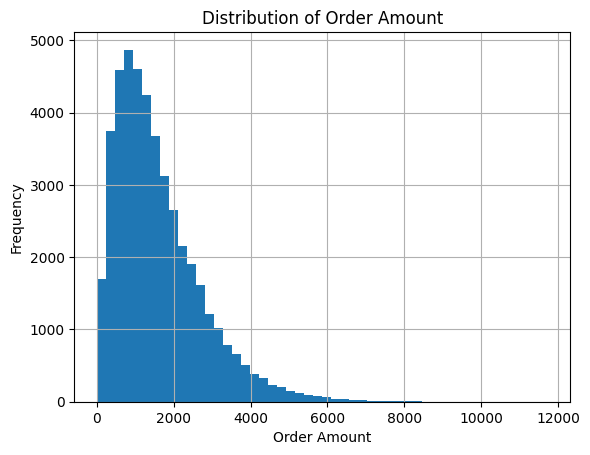

In [4]:
# Revenue & Order Value Analysis

## Distribution of Order Amount

plt.figure()
base_orders["order_amount"].hist(bins=50)
plt.title("Distribution of Order Amount")
plt.xlabel("Order Amount")
plt.ylabel("Frequency")
plt.show()


### -> Right Skewed Data
### -> No negative values (validation worked)

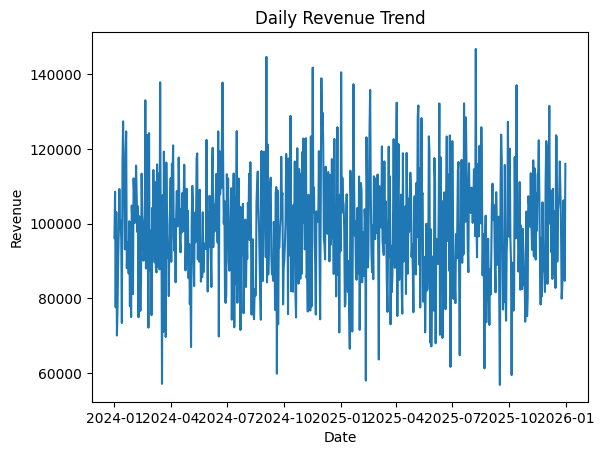

In [5]:
# Revenue Over Time (Daily)

daily_revenue = (
    base_orders
    .groupby(base_orders["order_date"].dt.date)["order_amount"]
    .sum()
)

plt.figure()
daily_revenue.plot()
plt.title("Daily Revenue Trend")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.show()


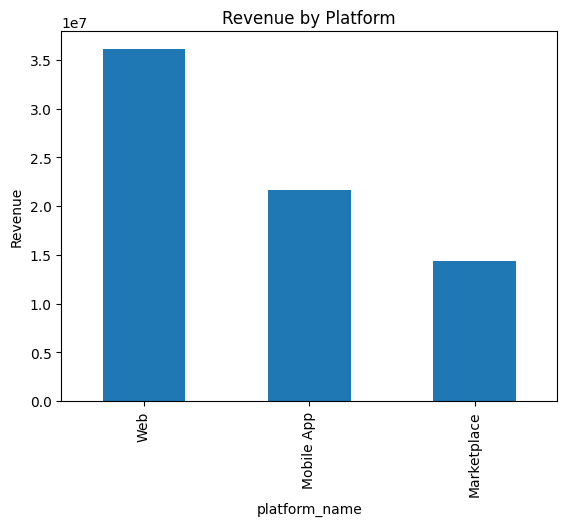

In [6]:
# Platform-Level Analysis

## Revenue Share by Platform

platform_revenue = (
    base_orders
    .groupby("platform_name")["order_amount"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure()
platform_revenue.plot(kind="bar")
plt.title("Revenue by Platform")
plt.ylabel("Revenue")
plt.show()


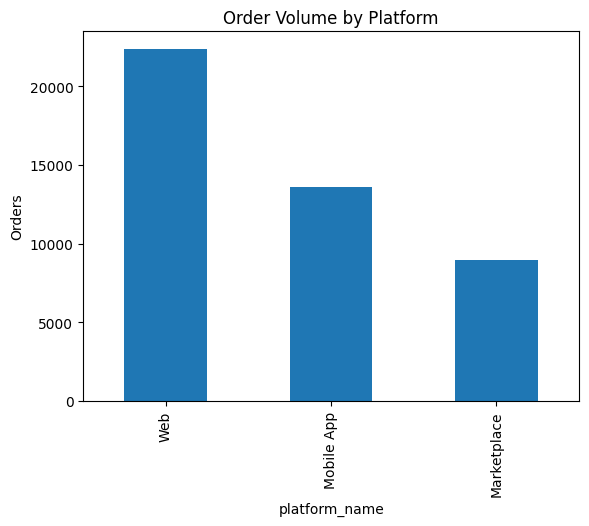

In [7]:
# Orders by Platform

base_orders["platform_name"].value_counts().plot(kind="bar")
plt.title("Order Volume by Platform")
plt.ylabel("Orders")
plt.show()


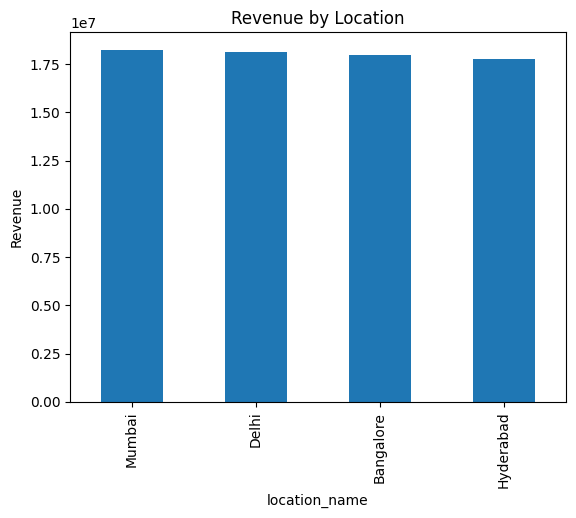

In [8]:
# Location-Level Analysis

## Revenue by Location

location_revenue = (
    base_orders
    .groupby("location_name")["order_amount"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure()
location_revenue.plot(kind="bar")
plt.title("Revenue by Location")
plt.ylabel("Revenue")
plt.show()


In [10]:
# Anomaly Validation (Very Important)

print("How Many Anomalous Days?")
print(base_orders["is_anomalous_day"].value_counts())

How Many Anomalous Days?
is_anomalous_day
False    43015
True      1933
Name: count, dtype: int64


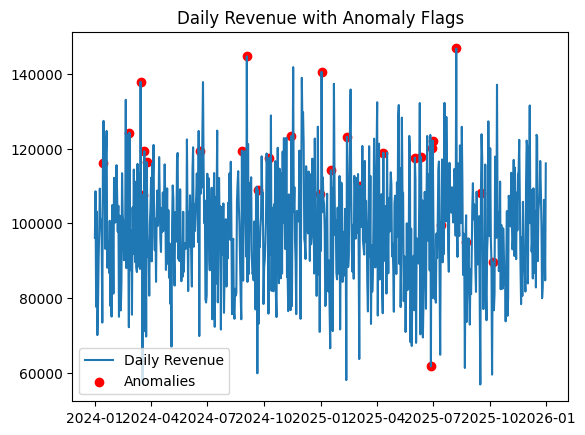

In [11]:
daily_rev_df = daily_revenue.reset_index()
daily_rev_df["is_anomalous_day"] = daily_rev_df["order_date"].isin(
    base_orders.loc[base_orders["is_anomalous_day"], "order_date"].dt.date
)

plt.figure()
plt.plot(daily_rev_df["order_date"], daily_rev_df["order_amount"], label="Daily Revenue")
plt.scatter(
    daily_rev_df.loc[daily_rev_df["is_anomalous_day"], "order_date"],
    daily_rev_df.loc[daily_rev_df["is_anomalous_day"], "order_amount"],
    color="red",
    label="Anomalies"
)
plt.legend()
plt.title("Daily Revenue with Anomaly Flags")
plt.show()


## 📊 EDA Summary & Business Observations

### 1. Order Value Distribution
- The distribution of order amounts is **right-skewed**, which is typical for commerce and transaction-based businesses.
- Most orders fall within a **lower-to-mid price range**, while a smaller number of high-value orders create a long tail.
- No negative or zero order values are present, confirming that **data validation rules are working as intended**.
- This distribution supports the use of **Average Order Value (AOV)** as a meaningful KPI while being mindful of outliers.

---

### 2. Daily Revenue Trends
- Daily revenue shows **consistent activity across the full time range (2024–2025)** with natural volatility.
- There is **no evidence of prolonged flatlines or data gaps**, indicating reliable data ingestion.
- Revenue fluctuations appear random and realistic, reflecting normal business variability rather than data issues.
- The dataset provides sufficient continuity and depth for **WoW and MoM growth analysis**.

---

### 3. Platform-Level Performance
- The **Web platform** is the dominant contributor in both:
  - Total revenue
  - Order volume
- The **Mobile App** represents a strong secondary channel, suggesting healthy multi-platform adoption.
- The **Marketplace channel** contributes fewer orders and lower revenue, which may indicate:
  - Higher commissions
  - Lower traffic
  - A strategic opportunity for growth or optimization
- Platform revenue and order mix appear **internally consistent**, validating platform-level KPI breakdowns.

---

### 4. Location-Level Performance
- Revenue contribution across locations (Mumbai, Delhi, Bangalore, Hyderabad) is **relatively balanced**.
- No single location overwhelmingly dominates or severely underperforms.
- This suggests:
  - Stable regional operations
  - No immediate location-level data quality concerns
- Location-based KPIs are suitable for **comparative performance analysis** rather than anomaly investigation.

---

### 5. Anomaly Detection Validation
- Out of the total observed days:
  - ~43,000 orders fall on non-anomalous days
  - ~1,900 orders are associated with anomalous days
- Anomalies are **infrequent and visually identifiable** in the daily revenue trend.
- Revenue spikes and drops are flagged explicitly rather than hidden or auto-corrected.
- This confirms that:
  - The anomaly detection logic is functioning correctly
  - Threshold-based validation (±50%) is reasonable for this business context

---

### 6. Overall Data Readiness Assessment
- No structural data quality issues were identified during EDA.
- Trends, distributions, and segment-level breakdowns are **business-realistic and interpretable**.
- Validation flags behave as expected and do not overwhelm the dataset.
- The dataset is **fit for final KPI computation, automation, and stakeholder reporting**.

---

### ✅ Conclusion
Based on exploratory analysis, the data is:
- Clean
- Validated
- Interpretable
- Aligned with real-
